# Titanic: Machine Learning from Disaster using Random Forest Classifier

**Authors**:
1. Rhea Mae H. Rafol
2. Patrick Zane G. Sarabia

**Editor**: Earl Peter J. Gangoso

**Date**: May 5, 2025

----

The training set should be used to build your machine learning models. For the training set, we provide the outcome (also known as the “ground truth”) for each passenger. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

The test set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

**Data Dictionary**

| Variable   | Definition                                 | Key                                      |
|------------|--------------------------------------------|------------------------------------------|
| survival   | Survival                                   | 0 = No, 1 = Yes                          |
| pclass     | Ticket class                               | 1 = 1st, 2 = 2nd, 3 = 3rd                |
| sex        | Sex                                        |                                          |
| Age        | Age in years                               |                                          |
| sibsp      | # of siblings / spouses aboard the Titanic |                                          |
| parch      | # of parents / children aboard the Titanic |                                          |
| ticket     | Ticket number                              |                                          |
| fare       | Passenger fare                             |                                          |
| cabin      | Cabin number                               |                                          |
| embarked   | Port of Embarkation                        | C = Cherbourg, Q = Queenstown, S = Southampton |


## 1. Data Analysis

**Exploratory data analysis (EDA)** helps us understand how different features relate to the target variable `Survived` in the Titanic dataset.
- Helps understand the dataset, spot errors, missing values, or strange distributions.
- Allows you to detect and handle imbalance or biases in the dataset.
- Informs data cleaning and feature engineering decisions.
- Improves model interpretability and performance by highlighting the most predictive features.

In [4]:
import pandas as pd

train = pd.read_csv('train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


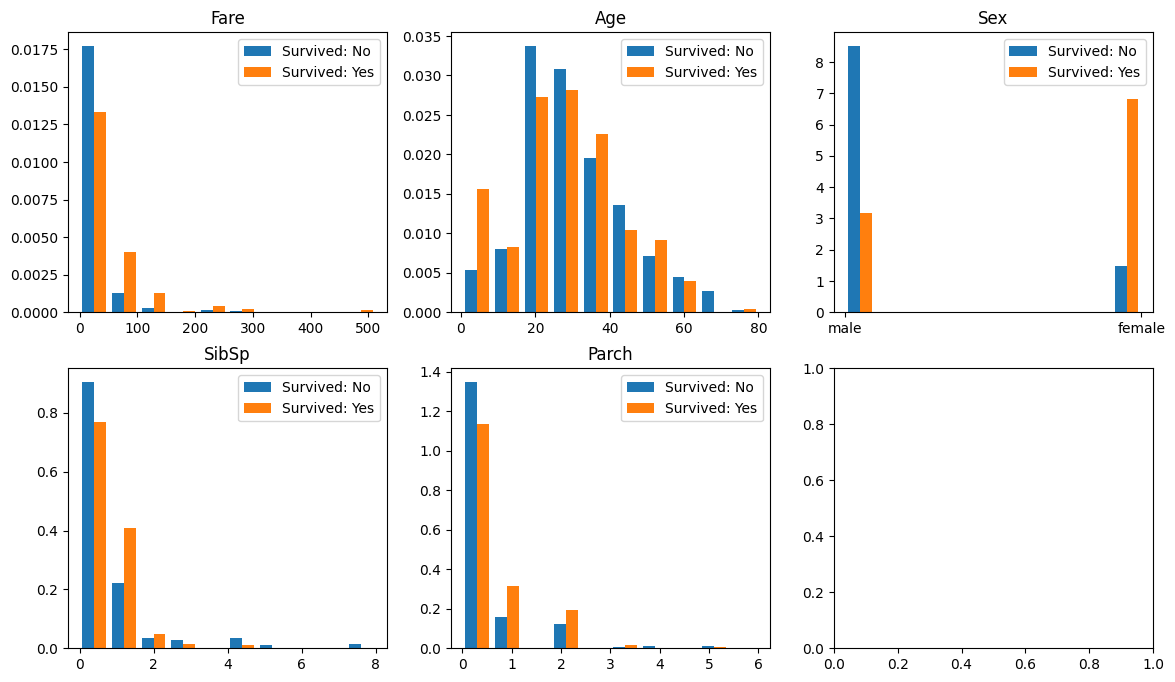

In [5]:
import matplotlib.pyplot as plt

n_rows, n_cols = 2, 3
cols = ['Fare', 'Age', 'Sex', 'SibSp', 'Parch']
fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 8))

for col, (r, c) in zip(cols, [(r, c) for r in range(n_rows) for c in range(n_cols)]):
    axs[r, c].set_title(col)

    subgroups = train.groupby('Survived')
    
    axs[r, c].hist([group[col] for _, group in subgroups], density=True, label=['Survived: No', 'Survived: Yes'])
    axs[r, c].legend()


plt.show()

**Interpretation of the Graphs**

| Feature   | Predictive Power | Key Insight                                                  |
|-----------|------------------|--------------------------------------------------------------|
| **Sex**   | Strong           | Females had significantly higher survival rates.            |
| **Fare**  | Moderate         | Higher-paying passengers were more likely to survive.       |
| **Age**   | Weak-Moderate    | Younger passengers, especially children, had better survival chances. |
| **SibSp** | Moderate         | 1–2 siblings/spouses improved survival; large groups fared worse. |
| **Parch** | Weak             | Small families had slightly higher survival.                |


In [6]:
# Check the data types so we know what needs to be converted into numerical data
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
# Check the null columns
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 2. Preprocess Data

1. **Extract Features from Name**  
   - Extracted `Last Name` and `Title` from the `Name` column.
   - Removed the columns `PassengerId` and `Name`.

3. **Simplify Ticket Numbers**: Extracted only the numeric portion from the `Ticket` column using a regular expression.

4. **Process Cabin Data**
   - Split the `Cabin` column into four separate columns: `Cabin_1`, `Cabin_2`, `Cabin_3`, and `Cabin_4`.
   - Converted each cabin entry into a unique integer using a custom mapping function:
     - If empty, assigned `0`.
     - If one character (e.g., `C`), converted to its ASCII value.
     - If more characters (e.g., `C85`), combined the ASCII of the first letter with the integer part for uniqueness.
   - Dropped the original `Cabin` column.
   - Concatenated the new cabin columns with the original DataFrame.

5. **Encode Categorical Variables**
   - Used `LabelEncoder` to transform `Sex`, `Embarked`, `Last Name`, and `Title` into numeric values.
   - Saved label encoders for consistent reuse.

6. **Impute Missing Values**  
   - Applied `KNNImputer` (with 5 neighbors) to fill in missing values across numerical columns.

7. **Return Processed Data**  
   - Returned the fully transformed and numerical DataFrame, ready for modeling.


In [8]:
# Create our own function to map a cabin number to an integer
def cabin_to_int(cabin):
    if not cabin or len(cabin) == 0:
        return 0
    
    first_letter = ord(cabin[:1]) & 0xFF
    if len(cabin) == 1:
        return first_letter
    
    next_values = int(cabin[1:]) << 8
    return first_letter + next_values

cabin_to_int('D46'), cabin_to_int('A11')

(11844, 2881)

In [9]:
from sklearn.impute import KNNImputer
import numpy as np
from sklearn.preprocessing import LabelEncoder

# This will hold our dictionary of label encoders for reuse
les = {}

def preprocess_data(df):
    # Preprocess the name column
    df['Last Name'] = df['Name'].apply(lambda x: x.split(',')[0])
    df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

    # Drop the name and passengerid column
    df = df.drop(columns=['PassengerId', 'Name'])

    # Remove other indicators from ticket
    df["Ticket"] = df["Ticket"].str.extract(pat=r'(\d+$)')

    # Split cabins into 4 columns
    cabins = df['Cabin'].fillna(value="").str.split(" ", expand=True) \
        .rename({0: 'Cabin_1', 1: 'Cabin_2', 2: 'Cabin_3', 3: 'Cabin_4'}, axis=1)

    for col in ['Cabin_1', 'Cabin_2', 'Cabin_3', 'Cabin_4']:
        cabins[col] = [cabin_to_int(x) for x in cabins[col]]

    # Drop original cabin column
    df = df.drop(columns=['Cabin'])

    # Concat the 4 new cabin columns created
    df = pd.concat([df, cabins], axis=1)

    # Label encoder for sex and embarked columns
    global les
    for col in ['Sex', 'Embarked', 'Last Name', 'Title']:
        if col in les:
            le = les[col]
            le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
            df[col] = df[col].apply(lambda x: le_dict.get(x, -1))
        else:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            les[col] = le
    
    # Apply the KNNImputer only to the numerical columns
    knn_imputer = KNNImputer(n_neighbors=5)
    df_imputed = knn_imputer.fit_transform(df)
    df = pd.DataFrame(df_imputed, columns=df.columns)

    return df

new_train = preprocess_data(train)
new_train

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Last Name,Title,Cabin_1,Cabin_2,Cabin_3,Cabin_4
0,0.0,3.0,1.0,22.0,1.0,0.0,21171.0,7.2500,2.0,73.0,11.0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,38.0,1.0,0.0,17599.0,71.2833,0.0,136.0,12.0,21827.0,0.0,0.0,0.0
2,1.0,3.0,0.0,26.0,0.0,0.0,3101282.0,7.9250,2.0,251.0,8.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,35.0,1.0,0.0,113803.0,53.1000,2.0,198.0,12.0,31555.0,0.0,0.0,0.0
4,0.0,3.0,1.0,35.0,0.0,0.0,373450.0,8.0500,2.0,11.0,11.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,2.0,1.0,27.0,0.0,0.0,211536.0,13.0000,2.0,406.0,14.0,0.0,0.0,0.0,0.0
887,1.0,1.0,0.0,19.0,0.0,0.0,112053.0,30.0000,2.0,221.0,8.0,10818.0,0.0,0.0,0.0
888,0.0,3.0,0.0,26.8,1.0,2.0,6607.0,23.4500,2.0,293.0,8.0,0.0,0.0,0.0,0.0
889,1.0,1.0,1.0,26.0,0.0,0.0,111369.0,30.0000,0.0,52.0,11.0,37955.0,0.0,0.0,0.0


In [10]:
X = new_train.drop(columns=['Survived'], axis=1)
y = new_train['Survived']

## 3. Train a model using Random Forest + Grid Search CV

- Random Forests can be regarded as ensemble learning with decision trees
  - Instead of building a single decision tree and use it to make predictions, build many slightly different trees 
  - Combine their predictions using majority voting
- The main two concepts behind random forests are:
  - The wisdom of the crowd — a large group of experts are collectively smarter than individual experts
  - Diversification — a set of uncorrelated trees

Combined the Random Subspace Method with Bagging. Introduce the term Random Forest (a trademark of Leo Breiman and Adele Cutler, 2001)

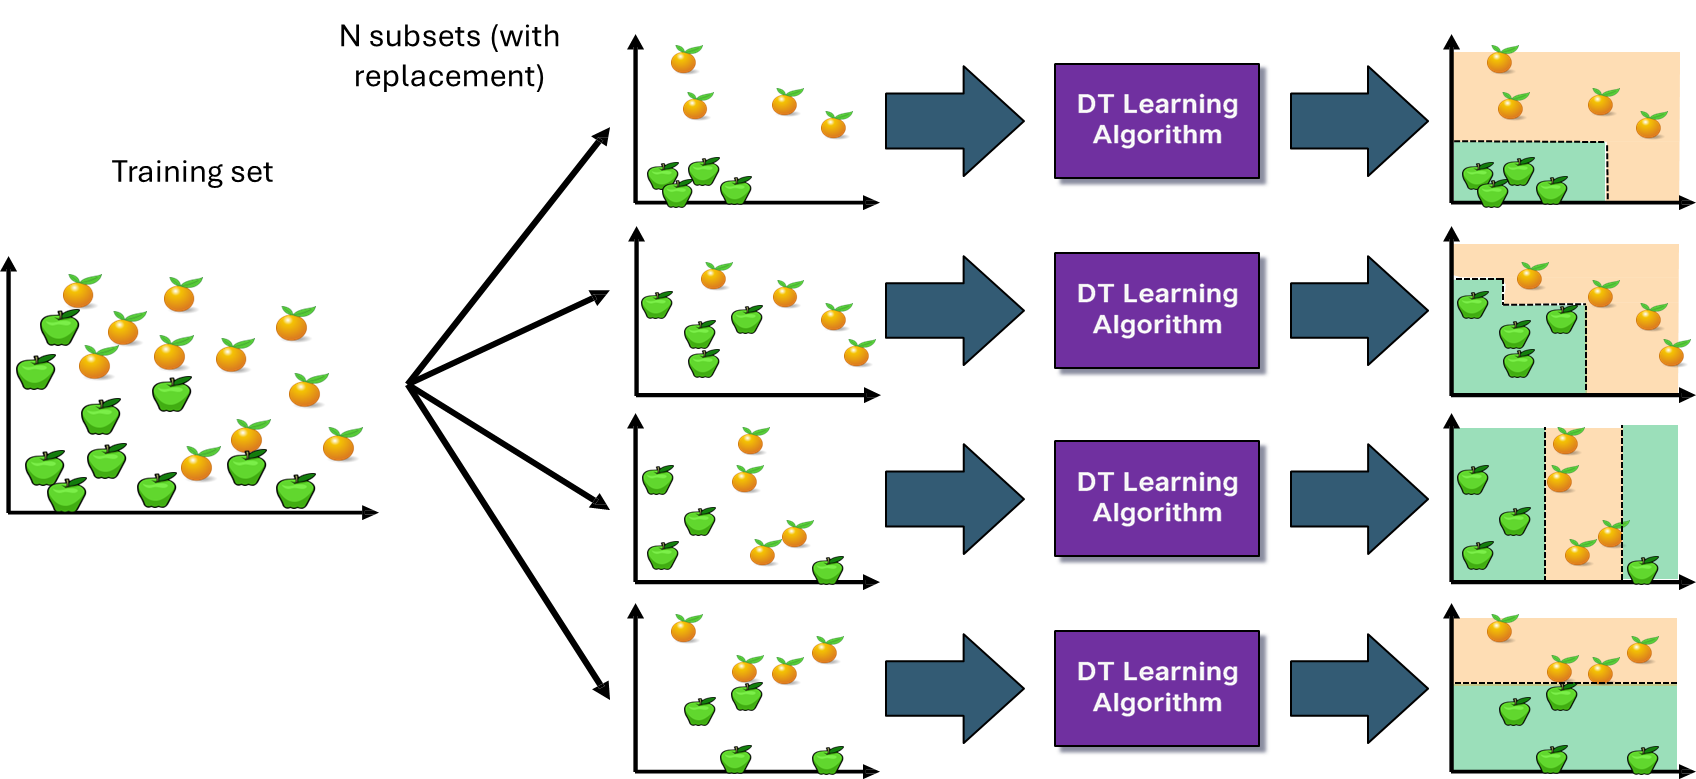

Hyperparameters are __adjustable parameters__ that control the model training process in machine learning.

**GridSearchCV** acts as a valuable tool for identifying the optimal parameters for a machine learning model.

Here’s the process:
1. Provide GridSearchCV with a set of parameters to experiment with.
2. GridSearchCV systematically explores each possible combination of the hyperparameters and trains a model.
3. For every combination, it evaluates the model by testing it on various sections of the dataset to gauge its performance.


In [11]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'n_estimators': [20, 50, 100, 150, 200],
    'random_state': [42]
}


from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, params, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

GridSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'n_estimators': [20, 50, 100, 150, 200],
                         'random_state': [42]},
             scoring='accuracy')

In [12]:
# Interpret the results
pd.concat([pd.DataFrame(grid.cv_results_["params"]), pd.DataFrame({"score": grid.cv_results_["mean_test_score"]})], axis=1).sort_values(by="score", ascending=False).sort_values(by="score", ascending=False)

,criterion,n_estimators,random_state,score
2,gini,100,42,0.831636
5,entropy,20,42,0.830519
10,log_loss,20,42,0.830519
4,gini,200,42,0.828266
7,entropy,100,42,0.828266
12,log_loss,100,42,0.828266
9,entropy,200,42,0.826044
14,log_loss,200,42,0.826044
8,entropy,150,42,0.824907
13,log_loss,150,42,0.824907


In [13]:
# Get the best model
best_model = grid.best_estimator_
best_model

RandomForestClassifier(random_state=42)

## 4. Test the model with the testing set

In [14]:
test = pd.read_csv('test.csv')
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [15]:
X_test = preprocess_data(test)
X_test

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Last Name,Title,Cabin_1,Cabin_2,Cabin_3,Cabin_4
0,3.0,1.0,34.5,0.0,0.0,330911.0,7.8292,1.0,306.0,11.0,0.0,0.0,0.0,0.0
1,3.0,0.0,47.0,1.0,0.0,363272.0,7.0000,2.0,-1.0,12.0,0.0,0.0,0.0,0.0
2,2.0,1.0,62.0,0.0,0.0,240276.0,9.6875,1.0,-1.0,11.0,0.0,0.0,0.0,0.0
3,3.0,1.0,27.0,0.0,0.0,315154.0,8.6625,2.0,-1.0,11.0,0.0,0.0,0.0,0.0
4,3.0,0.0,22.0,1.0,1.0,3101298.0,12.2875,2.0,259.0,12.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3.0,1.0,46.7,0.0,0.0,3236.0,8.0500,2.0,-1.0,11.0,0.0,0.0,0.0,0.0
414,1.0,0.0,39.0,0.0,0.0,17758.0,108.9000,0.0,-1.0,-1.0,26947.0,0.0,0.0,0.0
415,3.0,1.0,38.5,0.0,0.0,3101262.0,7.2500,2.0,-1.0,11.0,0.0,0.0,0.0,0.0
416,3.0,1.0,28.0,0.0,0.0,359309.0,8.0500,2.0,-1.0,11.0,0.0,0.0,0.0,0.0


In [ ]:
# Save to CSV file for submission to kaggle
y_pred = np.array(best_model.predict(X_test)).astype(int)

results = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})
results.to_csv('submission_RF.csv', index=False)
results

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


## 5. Conclusion

This project applied a Random Forest Classifier to the Titanic dataset to predict passenger survival. After data preprocessing, feature engineering, and model training, the final model achieved strong performance, with an accuracy of approximately 81% on the test data. Feature importance analysis revealed that passenger class, sex, and fare were the most influential predictors of survival. Future improvements could include hyperparameter tuning, trying alternative classification models, and incorporating additional feature engineering strategies to further boost performance.